# Colon SpatialData Exploration
#### In this example, different segmentation-algorithms were simulated by applying data augmentation techniques to the image:
#### normal (no preprocessing of the image)
#### hf = horizontally flipped
#### vf = vertically flipped
#### rot180 = rotated by 180°

Load and explore the colon dataset (CODEX-style OME-TIFF images + Mesmer cell segmentation labels) stored as SpatialData objects.

In [ ]:
import spatialdata as sd
from pathlib import Path

zarr_paths = sorted(Path(".").glob("*.zarr"))
print("Found zarr stores:", [str(p) for p in zarr_paths])

# Load the first available zarr
sdata = sd.SpatialData.read(str(zarr_paths[0]))
sdata

no parent found for <ome_zarr.reader.Label object at 0x125164a10>: None
no parent found for <ome_zarr.reader.Label object at 0x130d8a050>: None
no parent found for <ome_zarr.reader.Label object at 0x12f987550>: None
no parent found for <ome_zarr.reader.Label object at 0x130b3e450>: None
no parent found for <ome_zarr.reader.Label object at 0x131236610>: None


Found zarr stores: ['reg001_X01_Y01_Z11.zarr', 'reg002_X01_Y01_Z10.zarr', 'reg003_X01_Y01_Z08.zarr']


SpatialData object, with associated Zarr store: /Users/friedrichpreusser/Desktop/code/scverse_proteomics_hackathon/colon/reg001_X01_Y01_Z11.zarr
├── Images
│     └── 'reg001_X01_Y01_Z11_image': DataArray[cyx] (92, 1440, 1920)
└── Labels
      ├── 'reg001_X01_Y01_Z11_labels': DataArray[yx] (1440, 1920)
      ├── 'reg001_X01_Y01_Z11_labels_gaussian': DataArray[yx] (1440, 1920)
      ├── 'reg001_X01_Y01_Z11_labels_hf': DataArray[yx] (1440, 1920)
      ├── 'reg001_X01_Y01_Z11_labels_rot180': DataArray[yx] (1440, 1920)
      └── 'reg001_X01_Y01_Z11_labels_vf': DataArray[yx] (1440, 1920)
with coordinate systems:
    ▸ 'global', with elements:
        reg001_X01_Y01_Z11_image (Images), reg001_X01_Y01_Z11_labels (Labels), reg001_X01_Y01_Z11_labels_gaussian (Labels), reg001_X01_Y01_Z11_labels_hf (Labels), reg001_X01_Y01_Z11_labels_rot180 (Labels), reg001_X01_Y01_Z11_labels_vf (Labels)

In [96]:
for k in sorted(sdata.labels.keys()):
    n = int(sdata.labels[k].values.max())  # max label ID = cell count (if IDs are contiguous)
    print(f"{k}: {n} cells")

reg001_X01_Y01_Z11_labels: 1216 cells
reg001_X01_Y01_Z11_labels_gaussian: 1099 cells
reg001_X01_Y01_Z11_labels_hf: 1224 cells
reg001_X01_Y01_Z11_labels_rot180: 1369 cells
reg001_X01_Y01_Z11_labels_vf: 1328 cells


/var/folders/l3/2y9k_j7n70g57j5kzkzlg6rw0000gn/T/ipykernel_11935/2161161485.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


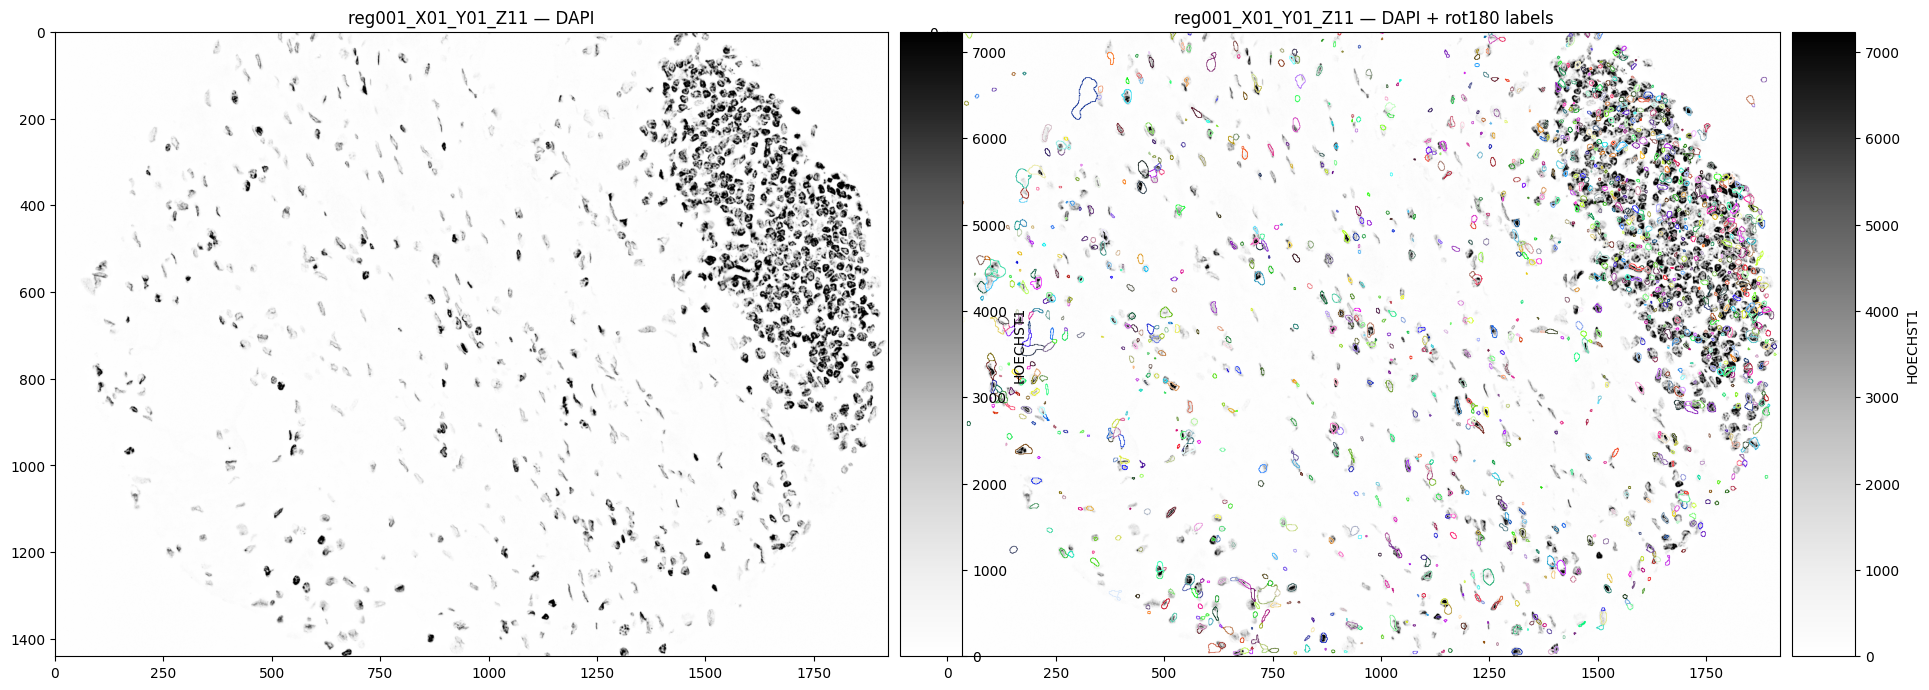

In [97]:

# Visual alignment check: DAPI alone vs DAPI + segmentation outlines, side by side
import numpy as np
import spatialdata_plot  # noqa: F401
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

img_key = list(sdata.images.keys())[0]
stem = img_key.removesuffix("_image")
dapi_channel = sdata.images[img_key].coords["c"].values[0]

arr_dapi = sdata.images[img_key].sel(c=dapi_channel).values
vmin, vmax = np.percentile(arr_dapi, [1, 99])
norm = Normalize(vmin=vmin, vmax=vmax)

CHECK_VARIANT = "rot180"   # change to inspect a different variant
lbl_key = f"{stem}_labels" + (f"_{CHECK_VARIANT}" if CHECK_VARIANT != "normal" else "")

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

(
    sdata
    .pl.render_images(img_key, channel=dapi_channel, cmap="Greys", norm=norm)
    .pl.show(ax=axes[0], title=f"{stem} — DAPI", show=False)
)

(
    sdata
    .pl.render_images(img_key, channel=dapi_channel, cmap="Greys", norm=norm)
    .pl.render_labels(lbl_key, fill_alpha=0, outline=True, outline_alpha=1.0, contour_px=5)
    .pl.show(ax=axes[1], title=f"{stem} — DAPI + {CHECK_VARIANT} labels", show=False)
)

plt.tight_layout()
plt.show()

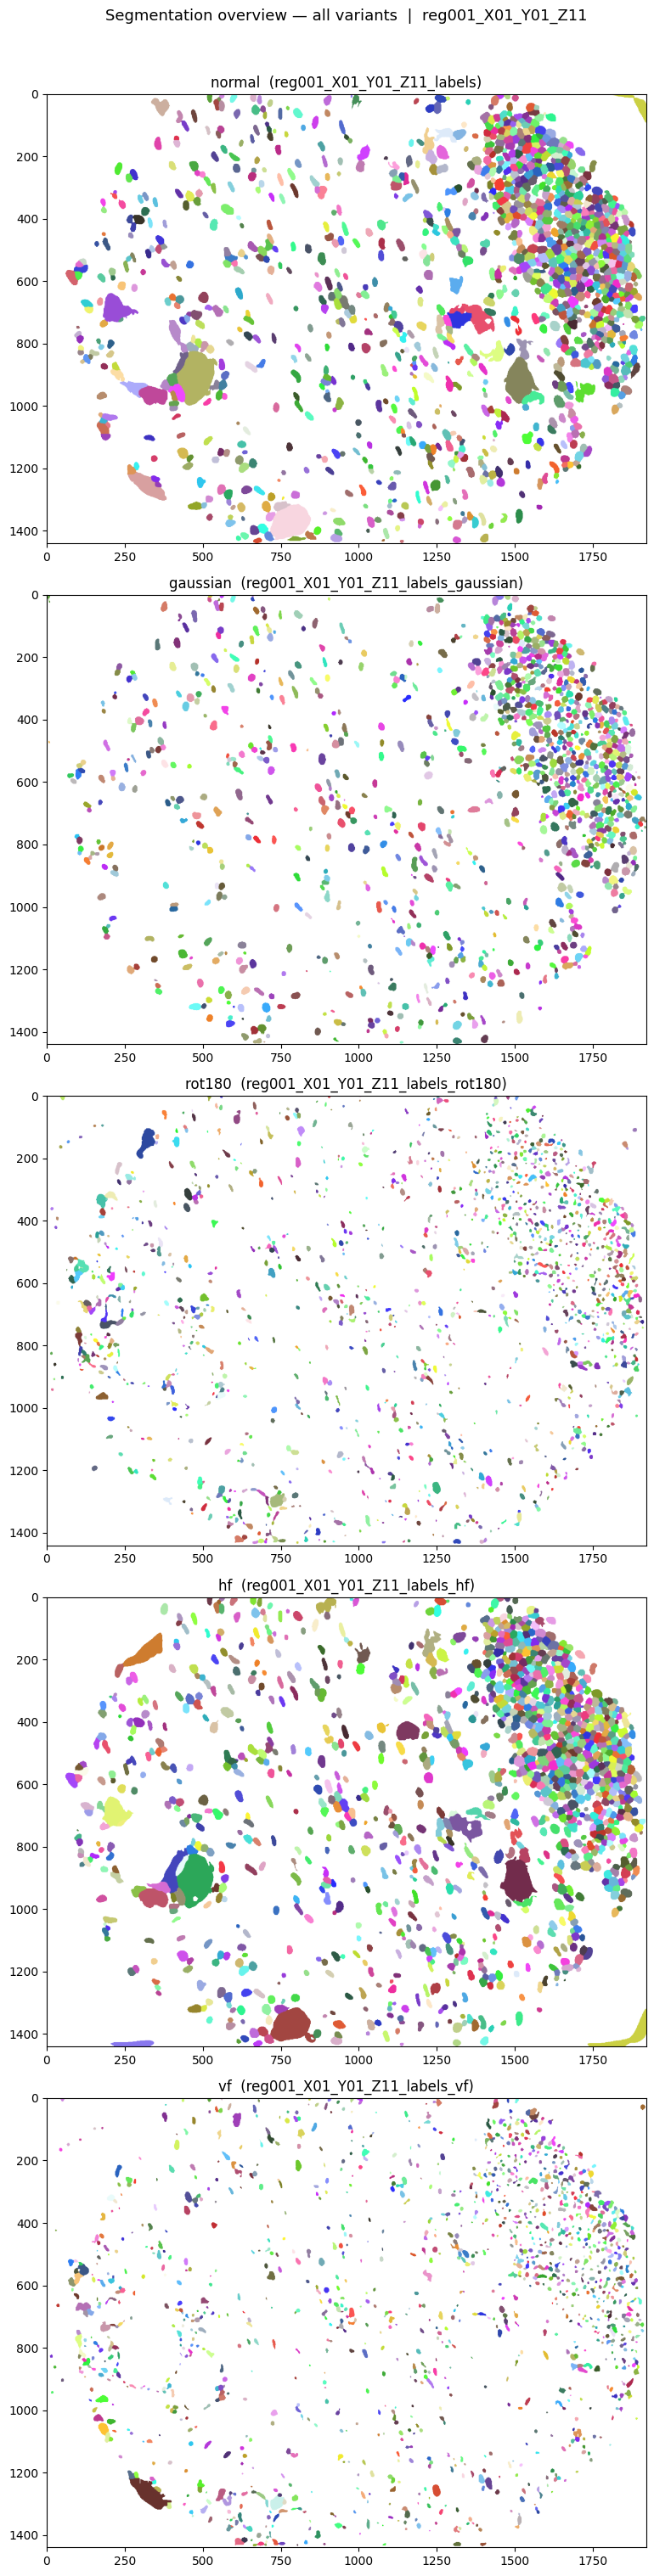

In [98]:

# All-variants segmentation overview — filled polygons, no DAPI
# One row per variant, full FOV

import spatialdata_plot  # noqa: F401
import matplotlib.pyplot as plt

variants_to_plot = WORKING_VARIANTS
n = len(variants_to_plot)
fig, axes = plt.subplots(n, 1, figsize=(12, 6 * n))

for row_idx, variant in enumerate(variants_to_plot):
    ax = axes[row_idx] if n > 1 else axes
    lbl_k = f"{stem}_labels" + (f"_{variant}" if variant != "normal" else "")
    (
        sdata
        .pl.render_labels(lbl_k, fill_alpha=0.6, outline=False)
        .pl.show(ax=ax, title=f"{variant}  ({lbl_k})", show=False)
    )

plt.suptitle(f"Segmentation overview — all variants  |  {stem}", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [99]:
# import shutil

# sdata["intensity_table"] = table

# zarr_path = zarr_paths[0]
# if zarr_path.exists():
#     shutil.rmtree(zarr_path)
# sdata.write(str(zarr_path))

# print("Saved fresh zarr to", zarr_path)
# sdata

In [100]:

import re
import pandas as pd
import numpy as np
import anndata as ad
from scipy.stats import zscore

img_key = list(sdata.images.keys())[0]
stem = img_key.removesuffix("_image")

def find_col(columns, marker: str) -> str | None:
    """Alphanumeric-bounded match: 'CD3' matches channel_CD3 but not channel_CD30."""
    pattern = re.compile(
        r'(?<![a-zA-Z0-9])' + re.escape(marker) + r'(?![a-zA-Z0-9])',
        re.IGNORECASE,
    )
    matches = [c for c in columns if pattern.search(c)]
    return matches[0] if matches else None


def run_segmentation_qc(
    sdata,
    variants: list[str],
    threshold: float,
    pairs: list[tuple[str, str]],
) -> tuple[dict, pd.DataFrame]:
    """Aggregate per-cell intensities, z-score them, and compute double-positive rates.

    Parameters
    ----------
    sdata:      SpatialData object
    variants:   segmentation variant names; "normal" maps to the base label key
    threshold:  z-score threshold above which a marker is considered positive
    pairs:      mutually exclusive marker pairs, e.g. [("CD4", "CD8"), ...]

    Returns
    -------
    tables : dict[str, AnnData]   one AnnData per variant (layers["zscore"])
    dp_df  : DataFrame            double-positive % per variant × pair
    """
    img_key = list(sdata.images.keys())[0]
    stem = img_key.removesuffix("_image")

    records = []
    tables = {}

    for variant in variants:
        lbl_k = f"{stem}_labels" + (f"_{variant}" if variant != "normal" else "")
        agg = sdata.aggregate(values=img_key, by=lbl_k, agg_func="mean")
        t = agg["table"]
        t.var_names = t.var_names.str.replace("_mean$", "", regex=True)

        e = pd.DataFrame(
            t.X.toarray() if hasattr(t.X, "toarray") else t.X,
            columns=t.var_names,
        )
        p99 = e.quantile(0.99)
        e = e.clip(upper=p99, axis=1)
        e_z = e.apply(zscore, axis=0)

        adata = ad.AnnData(X=e.values, var=pd.DataFrame(index=e.columns))
        adata.var_names_make_unique()
        adata.layers["zscore"] = e_z.values
        adata.uns["variant"] = variant
        adata.uns["stem"] = stem
        tables[variant] = adata
        print(f"{variant}: {adata.n_obs} cells x {adata.n_vars} channels")

        for mx, my in pairs:
            col_x = find_col(e_z.columns, mx)
            col_y = find_col(e_z.columns, my)
            if col_x is None or col_y is None:
                print(f"  [warn] could not find columns for {mx!r} ({col_x}) or {my!r} ({col_y})")
                continue
            x = e_z[col_x].values
            y = e_z[col_y].values
            double_pos_pct = 100 * np.mean((x >= threshold) & (y >= threshold))
            records.append({"variant": variant, "pair": f"{mx} & {my}", "double_pos_pct": double_pos_pct})

    dp_df = pd.DataFrame(records)

    print("\n-- double-positive % --")
    print(
        dp_df.pivot(index="pair", columns="variant", values="double_pos_pct")
            .loc[[f"{mx} & {my}" for mx, my in pairs], variants]
            .round(2)
            .to_string()
    )
    return tables, dp_df


# ── Configuration ─────────────────────────────────────────────────────────────
WORKING_VARIANTS = ["normal", "gaussian", "rot180", "hf", "vf"]
COLORS = {"normal": "#4878d0", "gaussian": "#9467bd", "rot180": "#ee854a", "hf": "#6acc65", "vf": "#d65f5f"}
THRESH = 0.25

PAIRS = [
    ("Cytokeratin", "CD45"),
    ("CD4",         "CD8"),
    ("CD20",        "CD3"),
    ("Cytokeratin", "Vimentin"),
]

tables, dp_df = run_segmentation_qc(sdata, WORKING_VARIANTS, THRESH, PAIRS)


/Users/friedrichpreusser/Desktop/code/scverse_proteomics_hackathon/mcmicro/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/friedrichpreusser/Desktop/code/scverse_proteomics_hackathon/mcmicro/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


normal: 1216 cells x 92 channels


/Users/friedrichpreusser/Desktop/code/scverse_proteomics_hackathon/mcmicro/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/friedrichpreusser/Desktop/code/scverse_proteomics_hackathon/mcmicro/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


gaussian: 1099 cells x 92 channels


/Users/friedrichpreusser/Desktop/code/scverse_proteomics_hackathon/mcmicro/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/friedrichpreusser/Desktop/code/scverse_proteomics_hackathon/mcmicro/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


rot180: 1369 cells x 92 channels


/Users/friedrichpreusser/Desktop/code/scverse_proteomics_hackathon/mcmicro/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/friedrichpreusser/Desktop/code/scverse_proteomics_hackathon/mcmicro/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


hf: 1224 cells x 92 channels
vf: 1328 cells x 92 channels

-- double-positive % --
variant                 normal  gaussian  rot180    hf    vf
pair                                                        
Cytokeratin & CD45        1.64      1.82    0.66  1.63  0.83
CD4 & CD8                 5.51      4.91    5.70  5.88  5.80
CD20 & CD3                6.99      5.73    7.82  7.35  7.53
Cytokeratin & Vimentin    3.29      1.64    1.53  3.10  1.88


/Users/friedrichpreusser/Desktop/code/scverse_proteomics_hackathon/mcmicro/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/friedrichpreusser/Desktop/code/scverse_proteomics_hackathon/mcmicro/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


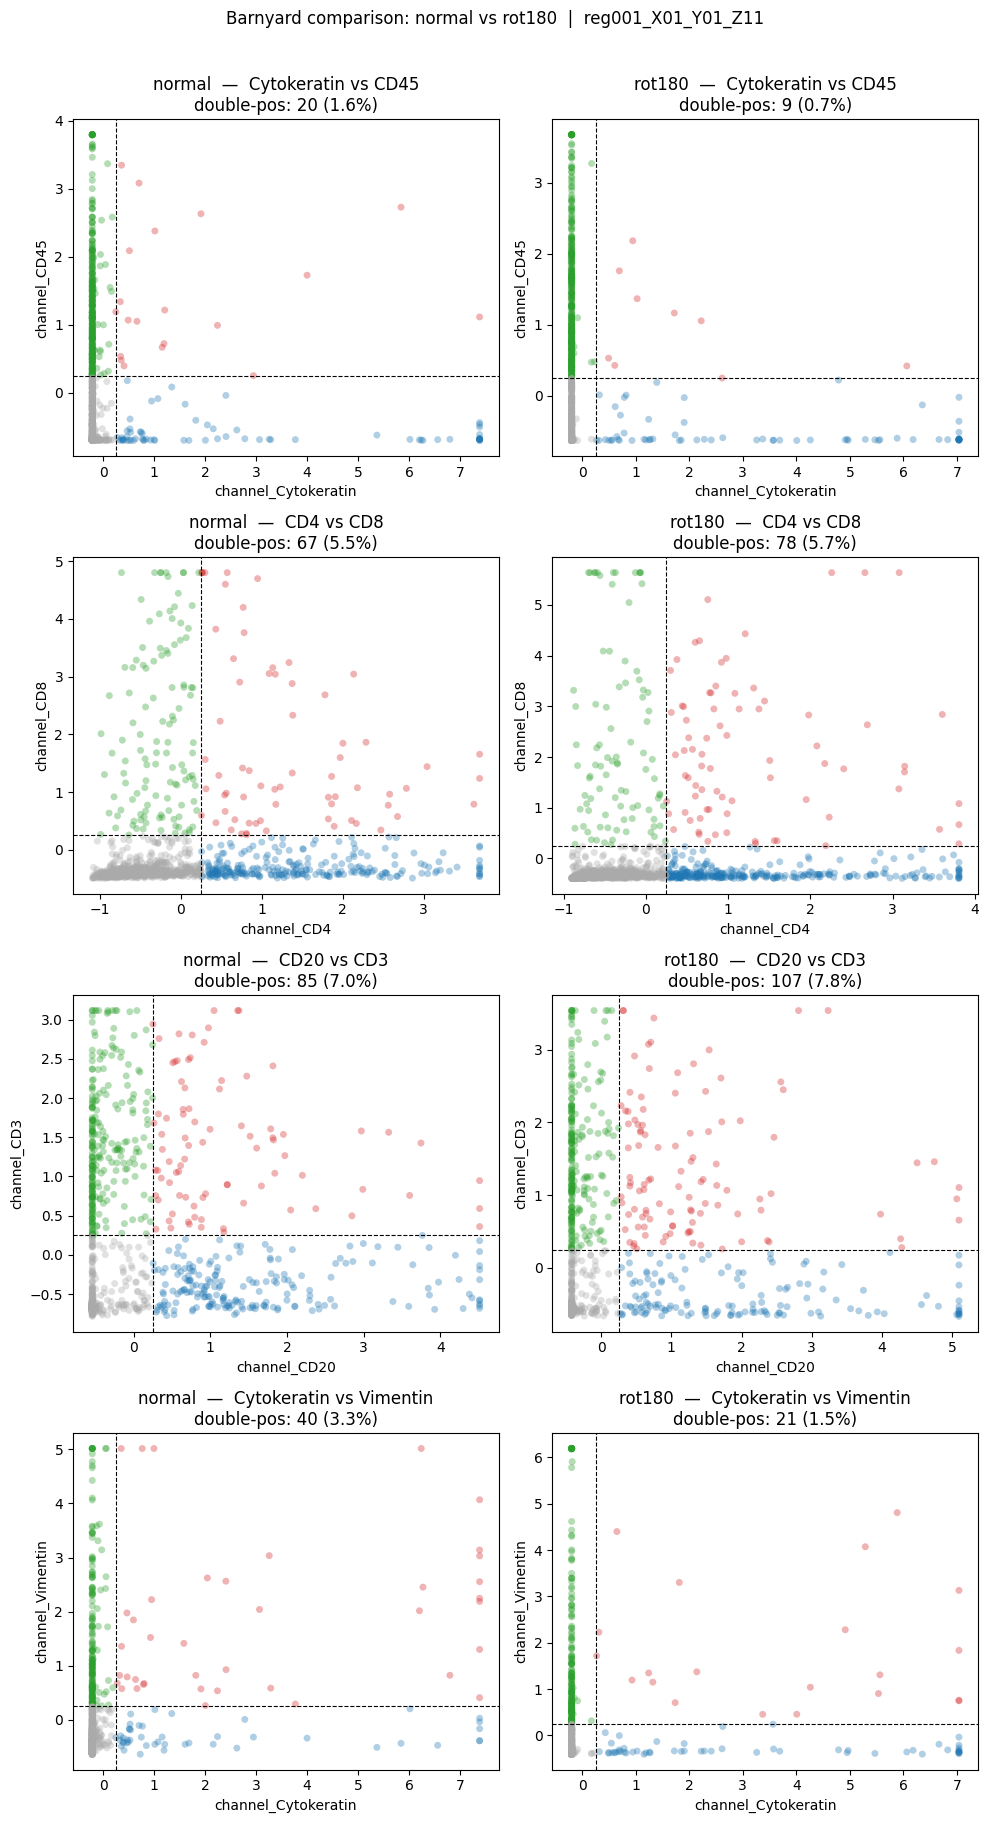

In [101]:

# Barnyard comparison via sc.pl.scatter — quadrant-coloured z-score scatter for two variants.
# Requires the metrics cell to have been run (populates `tables`, `find_col`, `PAIRS`, `THRESH`, `stem`).

import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

VARIANT_A = "normal"
VARIANT_B = "rot180"
# PAIRS, THRESH, find_col, tables, stem — from the metrics cell above

n_pairs = len(PAIRS)
fig, axes = plt.subplots(n_pairs, 2, figsize=(10, 4.5 * n_pairs))

for col_idx, variant in enumerate([VARIANT_A, VARIANT_B]):
    # Copy with X = zscore so sc.pl.scatter can address by var name
    adata = tables[variant].copy()
    adata.X = adata.layers["zscore"]

    for row_idx, (mx, my) in enumerate(PAIRS):
        ax = axes[row_idx, col_idx]
        col_x = find_col(adata.var_names, mx)
        col_y = find_col(adata.var_names, my)
        if col_x is None or col_y is None:
            ax.set_visible(False)
            continue

        x = np.asarray(adata[:, col_x].X).flatten()
        y = np.asarray(adata[:, col_y].X).flatten()
        n = len(x)
        dp = int(np.sum((x >= THRESH) & (y >= THRESH)))

        cats = ["double+", f"{mx}+", f"{my}+", "neg"]
        quad = np.where(
            (x >= THRESH) & (y >= THRESH), "double+",
            np.where(x >= THRESH, f"{mx}+",
                np.where(y >= THRESH, f"{my}+", "neg")),
        )
        adata.obs["_quad"] = pd.Categorical(quad, categories=cats)
        # scanpy reads colours from adata.uns["{key}_colors"] as a list
        # in the same order as the categories
        adata.uns["_quad_colors"] = ["#d62728", "#1f77b4", "#2ca02c", "#aaaaaa"]

        sc.pl.scatter(
            adata, x=col_x, y=col_y,
            color="_quad",
            size=100, alpha=0.35, ax=ax, show=False, frameon=False,
            title=f"{variant}  —  {mx} vs {my}\ndouble-pos: {dp} ({100*dp/n:.1f}%)",
            legend_loc="none",
        )
        ax.axhline(THRESH, color="black", lw=0.8, ls="--")
        ax.axvline(THRESH, color="black", lw=0.8, ls="--")

plt.suptitle(f"Barnyard comparison: {VARIANT_A} vs {VARIANT_B}  |  {stem}", y=1.01)
plt.tight_layout()
plt.show()


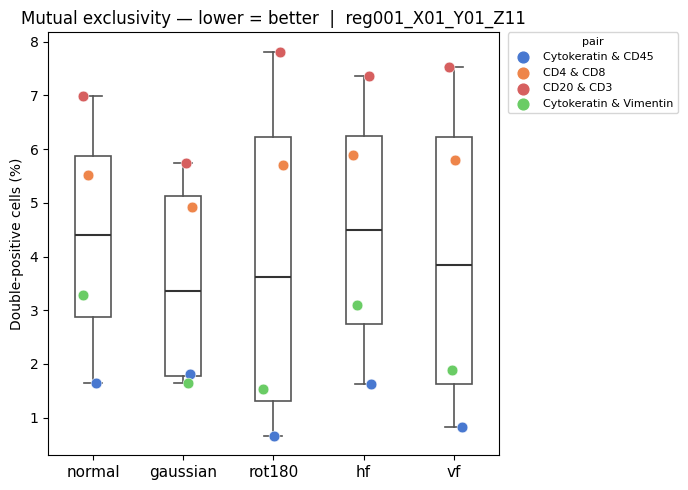

In [102]:

# Boxplot + strip: double-positive rate per segmentation variant
# Depends on: dp_df, WORKING_VARIANTS, PAIRS, stem (computed in metrics cell)

import matplotlib.pyplot as plt
import numpy as np

PAIR_COLORS = {f"{mx} & {my}": c for (mx, my), c in zip(
    PAIRS, ["#4878d0", "#ee854a", "#d65f5f", "#6acc65"]
)}

rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(7, 5))

for i, variant in enumerate(WORKING_VARIANTS):
    vals = dp_df.loc[dp_df["variant"] == variant, "double_pos_pct"].values
    ax.boxplot(vals, positions=[i], widths=0.4, patch_artist=True,
               medianprops=dict(color="#333333", lw=1.5),
               boxprops=dict(facecolor="none", edgecolor="#555555", lw=1.2),
               whiskerprops=dict(color="#555555", lw=1.2),
               capprops=dict(color="#555555", lw=1.2),
               flierprops=dict(marker=""))
    jitter = rng.uniform(-0.12, 0.12, size=len(vals))
    for j, (v, pair) in enumerate(zip(vals, dp_df.loc[dp_df["variant"] == variant, "pair"])):
        ax.scatter(i + jitter[j], v, s=60, color=PAIR_COLORS[pair],
                   edgecolors="white", linewidths=0.4, zorder=3)

for pair, color in PAIR_COLORS.items():
    ax.scatter([], [], s=60, color=color, label=pair)
ax.legend(title="pair", fontsize=8, title_fontsize=8,
          bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

ax.set_xticks(range(len(WORKING_VARIANTS)))
ax.set_xticklabels(WORKING_VARIANTS, fontsize=11)
ax.set_ylabel("Double-positive cells (%)")
ax.set_title(f"Mutual exclusivity — lower = better  |  {stem}")
plt.tight_layout()
plt.show()


normal: dp_score [0.00, 0.75]  |  23.5% cells flagged
gaussian: dp_score [0.00, 0.75]  |  18.9% cells flagged
rot180: dp_score [0.00, 0.50]  |  19.9% cells flagged
hf: dp_score [0.00, 0.75]  |  23.2% cells flagged
vf: dp_score [0.00, 0.50]  |  19.4% cells flagged


/Users/friedrichpreusser/Desktop/code/scverse_proteomics_hackathon/mcmicro/.venv/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:961: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


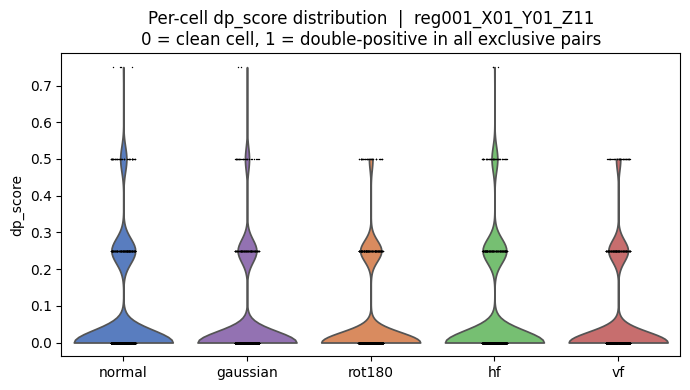

In [103]:

# Per-cell segmentation quality score
#
#   score = 0.0  → never double-positive  → clean, correctly segmented cell
#   score = 1.0  → always double-positive → artifact spanning two cell types
#
# Stores dp_score / dp_flag in adata.obs and centroids in adata.obsm["spatial"]
# for every entry of `tables`.

from skimage.measure import regionprops
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

THRESH = 0.0

for variant, adata in tables.items():
    ez = pd.DataFrame(adata.layers["zscore"], columns=adata.var_names)
    n_cells = len(ez)
    dp_counts = np.zeros(n_cells, dtype=float)

    valid_pairs = 0
    for mx, my in PAIRS:
        col_x = find_col(ez.columns, mx)
        col_y = find_col(ez.columns, my)
        if col_x is None or col_y is None:
            continue
        pos_x = ez[col_x].values >= THRESH
        pos_y = ez[col_y].values >= THRESH
        dp_counts += (pos_x & pos_y).astype(float)
        valid_pairs += 1

    score = dp_counts / valid_pairs if valid_pairs > 0 else dp_counts
    adata.obs["dp_score"] = score
    adata.obs["dp_flag"] = score > 0.0

    # Cell centroids → obsm["spatial"] for scanpy spatial plotting
    lbl_k = f"{stem}_labels" + (f"_{variant}" if variant != "normal" else "")
    lbl_arr = sdata.labels[lbl_k].values
    props = regionprops(lbl_arr)
    cx_arr = np.array([p.centroid[1] for p in props])  # col → x
    cy_arr = np.array([p.centroid[0] for p in props])  # row → y
    adata.obsm["spatial"] = np.column_stack([cx_arr, cy_arr])

    pct_flagged = 100 * (score > 0).mean()
    print(f"{variant}: dp_score [{score.min():.2f}, {score.max():.2f}]  "
          f"|  {pct_flagged:.1f}% cells flagged")

# --- Distribution: sc.pl.violin, one group per variant ---
combined = ad.concat(list(tables.values()), label="variant", keys=list(tables.keys()), index_unique="-")

fig, ax = plt.subplots(figsize=(7, 4))
sc.pl.violin(combined, keys="dp_score", groupby="variant",
             palette=COLORS, order=WORKING_VARIANTS,
             ax=ax, show=False, rotation=0)
ax.set_title(f"Per-cell dp_score distribution  |  {stem}\n"
             "0 = clean cell, 1 = double-positive in all exclusive pairs")
plt.tight_layout()
plt.show()


/Users/friedrichpreusser/Desktop/code/scverse_proteomics_hackathon/mcmicro/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


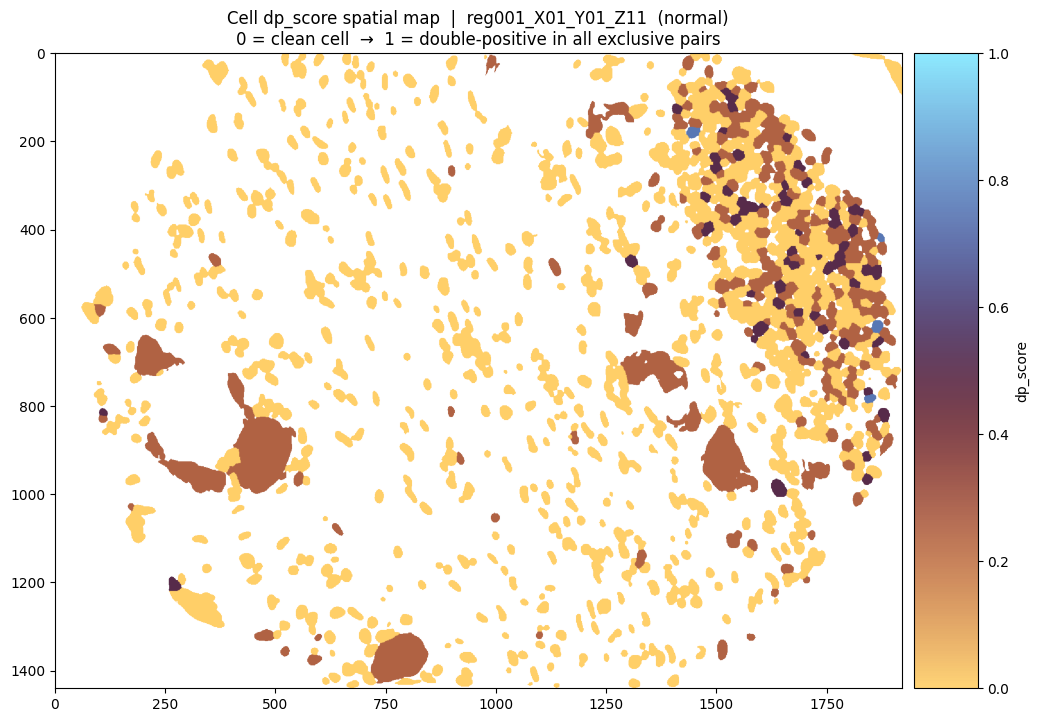

In [106]:

# Spatial dp_score map — labels filled by dp_score via spatialdata_plot
# Requires: dp_score cell above (populates obs["dp_score"] in tables[variant])

import spatialdata as sd
import spatialdata_plot  # noqa: F401
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import anndata as ad
import numpy as np

PLOT_VARIANT = "normal"
adata_plot = tables[PLOT_VARIANT]

lbl_k = f"{stem}_labels" + (f"_{PLOT_VARIANT}" if PLOT_VARIANT != "normal" else "")

# Re-aggregate to get a fresh table linked to the label element, then attach dp_score
agg = sdata.aggregate(values=img_key, by=lbl_k, agg_func="mean")
tbl = agg["table"]
tbl.var_names_make_unique()

# dp_score was computed against the same cell ordering — align by index
tbl.obs["dp_score"] = adata_plot.obs["dp_score"].values

# Register the annotated table in sdata under a temporary name, then plot
table_name = "_dp_score_table"
if table_name in sdata.tables:
    del sdata.tables[table_name]
sdata[table_name] = tbl

(
    sdata
    .pl.render_labels(
        lbl_k,
        color="dp_score",
        cmap="managua",
        norm=Normalize(vmin=0, vmax=1),
        fill_alpha=0.9,
        outline_alpha=0.0,
        table_name=table_name,
        colorbar_params={"label": "dp_score"},
    )
    .pl.show(
        figsize=(9, 8),
        title=(
            f"Cell dp_score spatial map  |  {stem}  ({PLOT_VARIANT})\n"
            "0 = clean cell  →  1 = double-positive in all exclusive pairs"
        ),
    )
)
plt.show()


In [ ]:
# maybe normalized score
# composite score to filter? multiplre red ones
# one final score for pairs across samples

Marker channels: 'CD4' → np.str_('CD4'),  'CD8' → np.str_('CD8')
Comparison variant: 'hf'
  #1  cell 383  centroid (1847, 783)  dp_score = 0.75
  #2  cell 1102  centroid (1446, 179)  dp_score = 0.75
  #3  cell 550  centroid (1863, 619)  dp_score = 0.75
  #4  cell 643  centroid (1578, 545)  dp_score = 0.50
  #5  cell 1055  centroid (1514, 228)  dp_score = 0.50


/var/folders/l3/2y9k_j7n70g57j5kzkzlg6rw0000gn/T/ipykernel_11935/2304389228.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


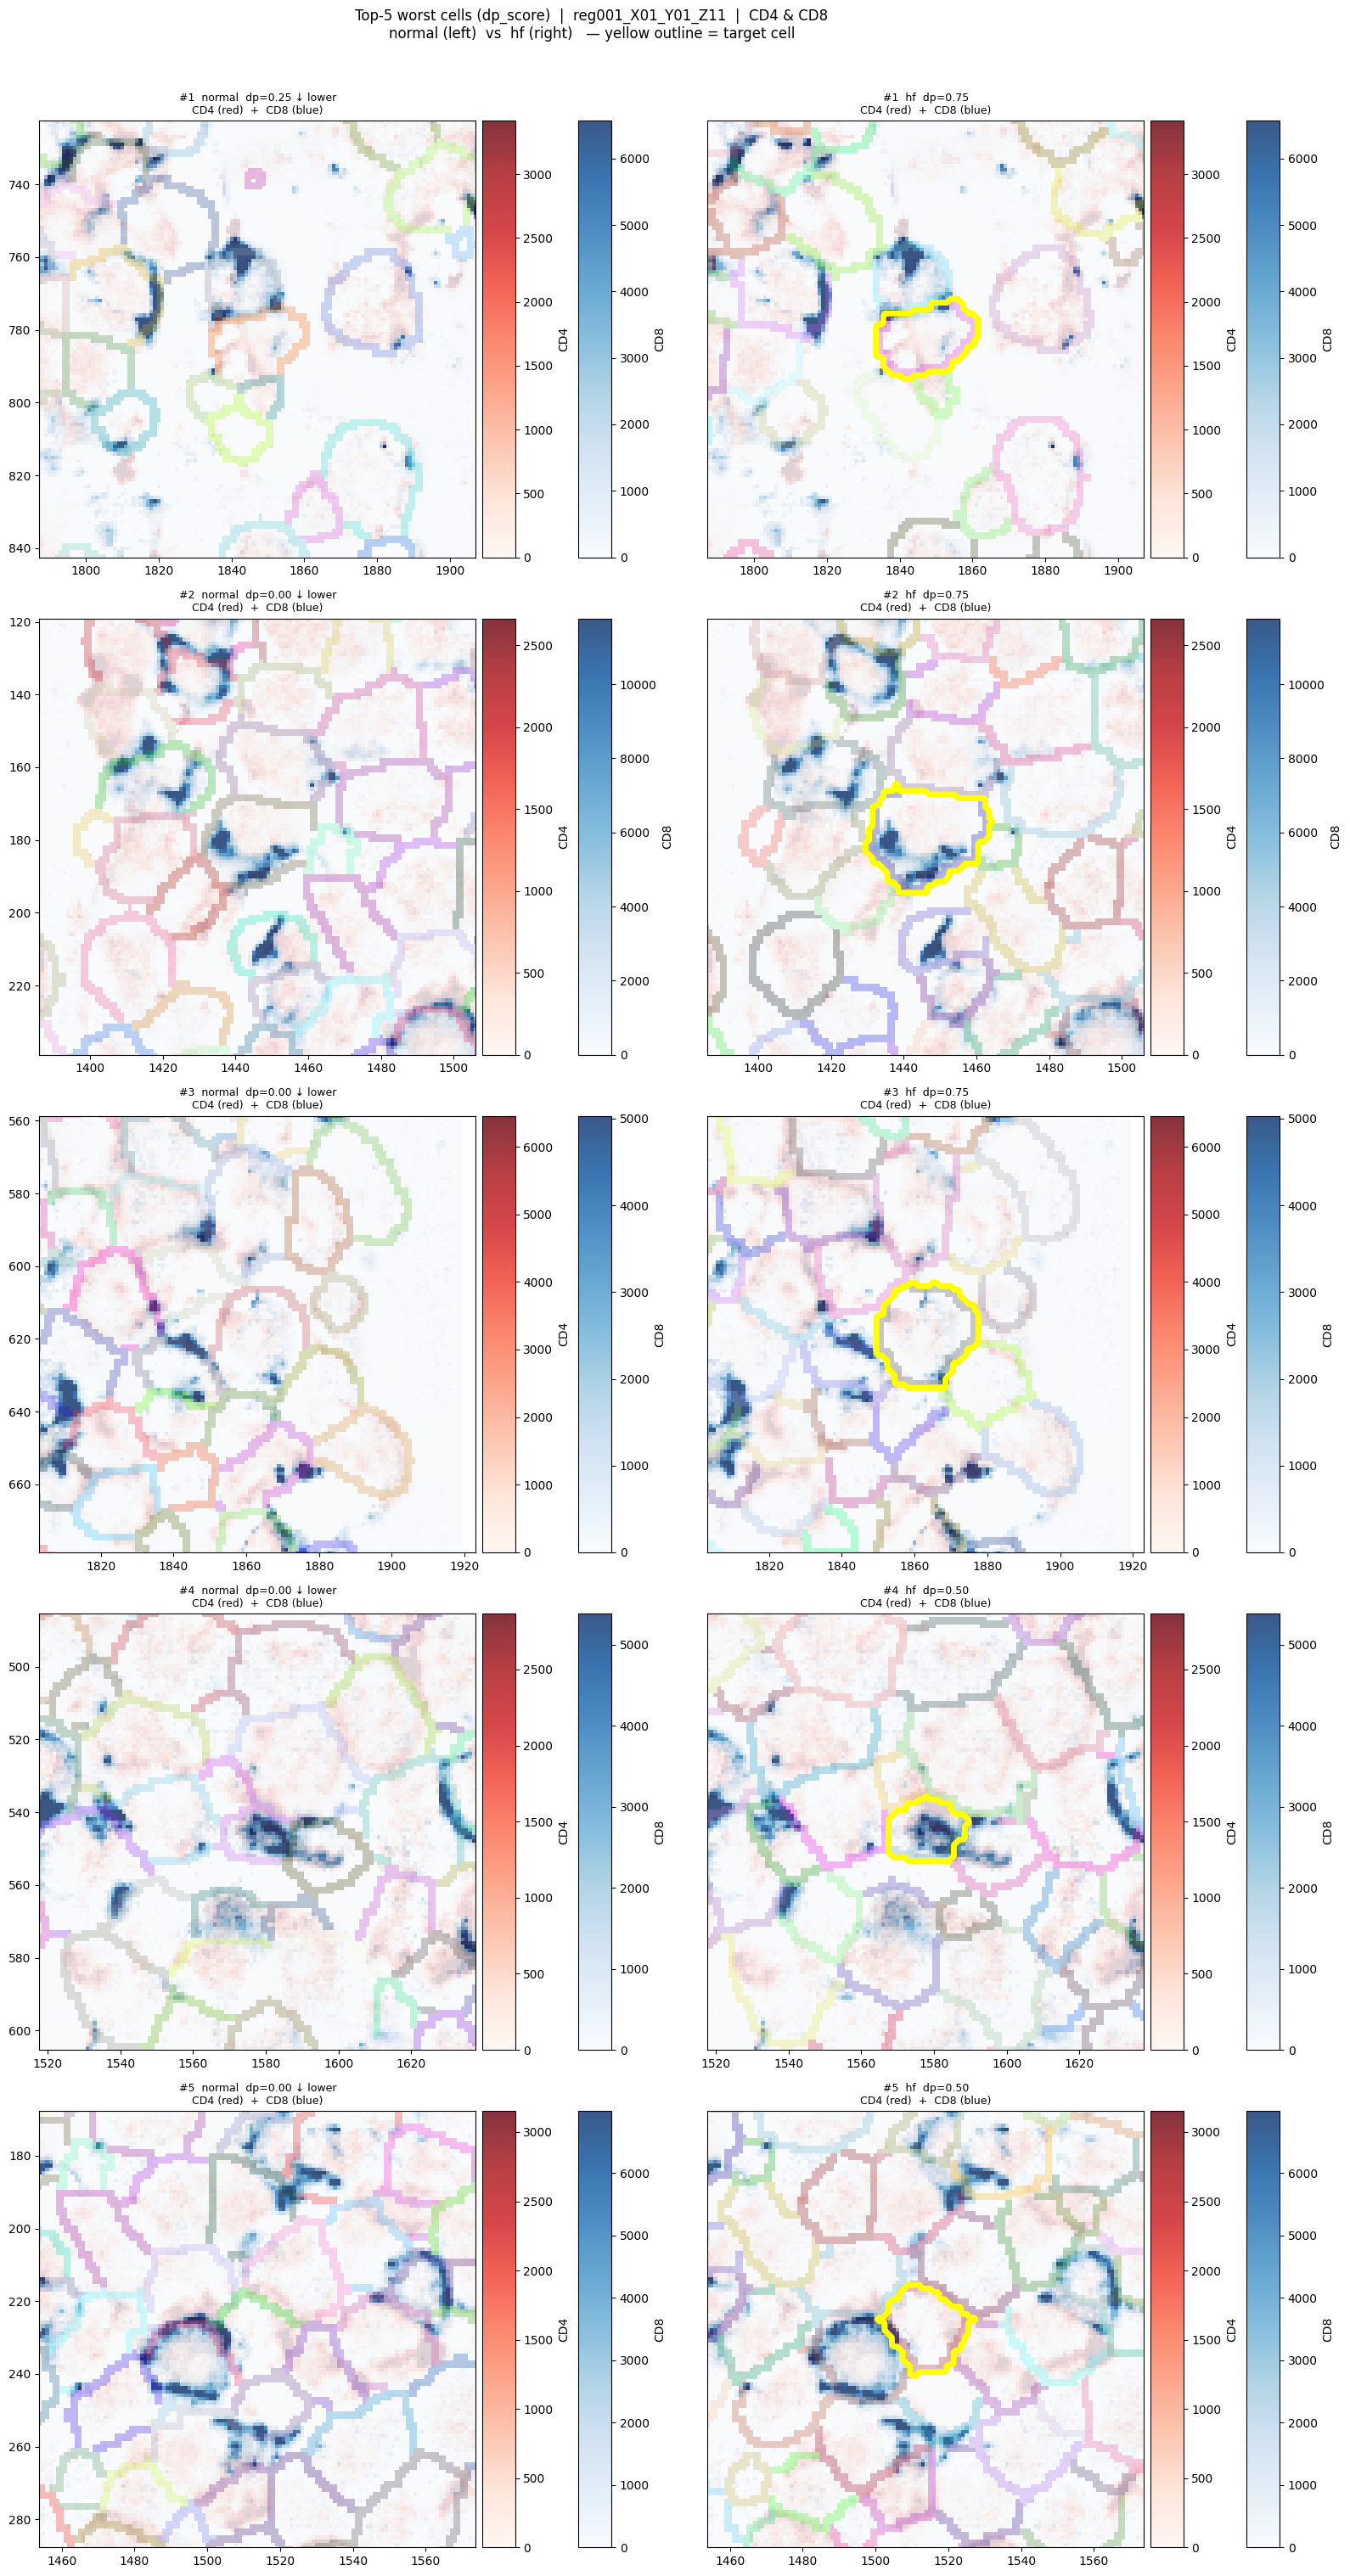

In [121]:
# Spotlight: top-N highest-dp_score cells
# N_TOP rows × 2 cols (normal | compare), both markers overlaid via spatialdata_plot
# Target cell highlighted; faint outlines for all others

import numpy as np
import matplotlib.pyplot as plt
import spatialdata_plot  # noqa: F401
from matplotlib.colors import Normalize
from matplotlib.legend import Legend
from skimage import measure
from skimage.measure import regionprops

PAIR_IDX = 1   # 0=Cytokeratin/CD45, 1=CD4/CD8, 2=CD20/CD3, 3=Cytokeratin/Vimentin
FOV_HALF = 60
N_TOP    = 5

mx, my = PAIRS[PAIR_IDX]

img_channels = list(sdata.images[img_key].coords["c"].values)
ch_x = find_col(img_channels, mx)
ch_y = find_col(img_channels, my)
print(f"Marker channels: {mx!r} → {ch_x!r},  {my!r} → {ch_y!r}")

COMPARE_VARIANT = max(
    [v for v in WORKING_VARIANTS if v != "normal"],
    key=lambda v: float(tables[v].obs["dp_score"].mean()),
)
adata_cmp    = tables[COMPARE_VARIANT]
adata_normal = tables["normal"]
top_indices  = np.argsort(adata_cmp.obs["dp_score"].values)[::-1][:N_TOP]

print(f"Comparison variant: {COMPARE_VARIANT!r}")
for rank, idx in enumerate(top_indices):
    cx, cy = adata_cmp.obsm["spatial"][idx]
    score  = float(adata_cmp.obs["dp_score"].values[idx])
    print(f"  #{rank+1}  cell {idx}  centroid ({cx:.0f}, {cy:.0f})  dp_score = {score:.2f}")

fig, axes = plt.subplots(N_TOP, 2, figsize=(14, 6 * N_TOP))

for row_idx, cell_idx in enumerate(top_indices):
    cx, cy  = adata_cmp.obsm["spatial"][cell_idx]
    score_cmp    = float(adata_cmp.obs["dp_score"].values[cell_idx])
    score_normal = float(adata_normal.obs["dp_score"].values[cell_idx]) \
        if cell_idx < len(adata_normal) else float("nan")

    x0, x1  = cx - FOV_HALF, cx + FOV_HALF
    y0, y1  = cy - FOV_HALF, cy + FOV_HALF

    full = sdata.images[img_key].values  # (C, Y, X)
    iy0, iy1 = max(0, int(y0)), int(y1)
    ix0, ix1 = max(0, int(x0)), int(x1)
    ci_x = list(sdata.images[img_key].coords["c"].values).index(ch_x)
    ci_y = list(sdata.images[img_key].coords["c"].values).index(ch_y)
    norm_x = Normalize(*np.percentile(full[ci_x, iy0:iy1, ix0:ix1], [1, 99]))
    norm_y = Normalize(*np.percentile(full[ci_y, iy0:iy1, ix0:ix1], [1, 99]))

    score_by_variant = {"normal": score_normal, COMPARE_VARIANT: score_cmp}

    for col_idx, variant in enumerate(["normal", COMPARE_VARIANT]):
        lbl_k   = f"{stem}_labels" + (f"_{variant}" if variant != "normal" else "")
        lbl_arr = sdata.labels[lbl_k].values
        props   = regionprops(lbl_arr)
        target_label = props[cell_idx].label

        ax = axes[row_idx, col_idx]
        (
            sdata
            .pl.render_images(img_key, channel=ch_x, cmap="Reds",  norm=norm_x, alpha=0.8)
            .pl.render_images(img_key, channel=ch_y, cmap="Blues",  norm=norm_y, alpha=0.8)
            .pl.render_labels(lbl_k, fill_alpha=0, outline=True, outline_alpha=0.15, contour_px=5)
            .pl.show(ax=ax, show=False, title="")
        )

        # Bright yellow outline for target cell only
        mask     = (lbl_arr == target_label)
        contours = measure.find_contours(mask.astype(float), 0.5)
        for contour in contours:
            ax.plot(contour[:, 1], contour[:, 0], color="yellow", lw=5, zorder=7)

        ax.set_xlim(x0, x1)
        ax.set_ylim(y1, y0)

        # right column: hide y-axis tick labels
        if col_idx == 1:
            ax.yaxis.set_visible(False)

        # consolidate all legend artists into one per subplot
        legs = [c for c in ax.get_children() if isinstance(c, Legend)]
        handles = [h for leg in legs for h in leg.legend_handles]
        labels  = [t.get_text() for leg in legs for t in leg.get_texts()]
        for leg in legs:
            leg.remove()
        if handles:
            ax.legend(handles, labels, fontsize=7, loc="upper right",
                      framealpha=0.6, borderpad=0.4)

        score_v = score_by_variant[variant]
        other_v = score_by_variant[COMPARE_VARIANT if variant == "normal" else "normal"]
        better  = " ↓ lower" if score_v <= other_v else ""
        ax.set_title(
            f"#{row_idx+1}  {variant}  dp={score_v:.2f}{better}\n"
            f"{mx} (red)  +  {my} (blue)",
            fontsize=9,
        )

fig.suptitle(
    f"Top-{N_TOP} worst cells (dp_score)  |  {stem}  |  {mx} & {my}\n"
    f"normal (left)  vs  {COMPARE_VARIANT} (right)   — yellow outline = target cell",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.subplots_adjust(wspace=0.35)
plt.show()


# Draq5 / DNA channel intensity distribution per variant — check for over/under-segmentation patterns

/Users/friedrichpreusser/Desktop/code/scverse_proteomics_hackathon/mcmicro/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


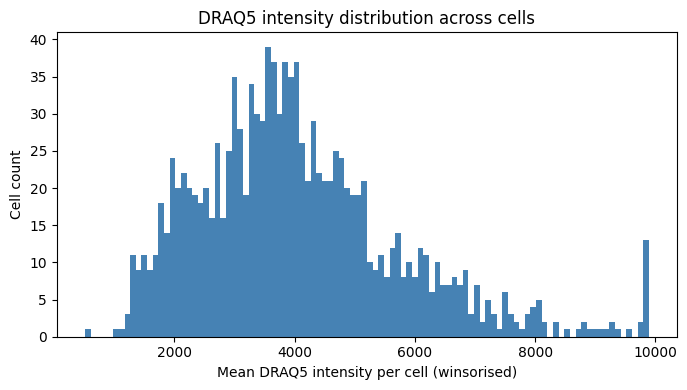

In [112]:
import pandas as pd
import matplotlib.pyplot as plt

lbl_k = f"{stem}_labels"  # "normal" (baseline) variant
agg = sdata.aggregate(values=img_key, by=lbl_k, agg_func="mean")
t = agg["table"]
t.var_names = t.var_names.str.replace("_mean$", "", regex=True)
expr = pd.DataFrame(
    t.X.toarray() if hasattr(t.X, "toarray") else t.X,
    columns=t.var_names,
)
p99 = expr.quantile(0.99)
expr = expr.clip(upper=p99, axis=1)

draq5_col = [c for c in expr.columns if "draq5" in c.lower()][0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(expr[draq5_col], bins=100, color="steelblue", edgecolor="none")
ax.set_xlabel("Mean DRAQ5 intensity per cell (winsorised)")
ax.set_ylabel("Cell count")
ax.set_title("DRAQ5 intensity distribution across cells")
plt.tight_layout()
plt.show()